In [1]:
from functools import lru_cache


def expected_draws(probabilities: list[float]) -> float:
    """
    计算集齐所有邮票需要的期望抽取次数。

    probabilities:
        每一种邮票被抽中的概率，所有概率之和必须为 1。
        例如 [0.25, 0.20, ..., 0.04]
    """
    n = len(probabilities)
    full_state = (1 << n) - 1

    if abs(sum(probabilities) - 1.0) > 1e-9:
        raise ValueError("所有邮票概率之和必须等于 1")

    if any(p <= 0 for p in probabilities):
        raise ValueError("每种邮票的概率都必须大于 0，否则永远无法集齐")

    @lru_cache(maxsize=None)
    def dp(state: int) -> float:
        if state == full_state:
            return 0.0

        duplicate_probability = 0.0
        new_stamp_cost = 0.0

        for i, probability in enumerate(probabilities):
            if state & (1 << i):
                # 已经拥有这张邮票，抽中后状态不变
                duplicate_probability += probability
            else:
                # 抽中新邮票，进入下一个状态
                next_state = state | (1 << i)
                new_stamp_cost += probability * dp(next_state)

        # E = 1 + 重复概率 * E + 新状态的期望
        # 移项后：
        # E = (1 + 新状态的期望) / (1 - 重复概率)
        return (1.0 + new_stamp_cost) / (1.0 - duplicate_probability)

    return dp(0)



In [7]:
import random
from statistics import mean


def simulate_collection(
    probabilities: list[float],
    simulations: int = 100_000,
) -> list[int]:
    """模拟很多名用户，返回每名用户集齐所需的抽取次数。"""

    stamp_ids = list(range(len(probabilities)))
    results = []

    for _ in range(simulations):
        collected = set()
        draws = 0

        while len(collected) < len(probabilities):
            stamp = random.choices(
                stamp_ids,
                weights=probabilities,
                k=1,
            )[0]

            collected.add(stamp)
            draws += 1

        results.append(draws)

    return results

In [11]:
import math

def coupon_collector_math(n):
    # 利用公式直接计算期望，O(n)
    harmonic_sum = sum(1/i for i in range(1, n + 1))
    return n * harmonic_sum

In [25]:

probabilities = [
    0.30,
    0.30,
    0.181,
    0.02,
    0.14,
    0.006,
    0.05,
    0.003
]

print(f"sum of probabilities: {sum(probabilities)}")

result = expected_draws(probabilities)
print(f"平均需要抽取 {result:.2f} 次")

sum of probabilities: 1.0
平均需要抽取 391.57 次


In [18]:
probabilities = [
    0.125,
    0.125,
    0.125,
    0.125,
    0.125,
    0.125,
    0.125,
    0.125
]

print(f"sum of probabilities: {sum(probabilities)}")

result = expected_draws(probabilities)
print(f"平均需要抽取 {result:.2f} 次")

calculated_expected_cnt = coupon_collector_math(len(probabilities))
print(f"平均需要抽取 {calculated_expected_cnt:.2f} 次")


sum of probabilities: 1.0
平均需要抽取 21.74 次
平均需要抽取 21.74 次


## 多少人能够集齐

In [26]:
results = simulate_collection(probabilities)

results.sort()

print(f"平均抽取次数：{mean(results):.2f}")
print(f"50% 用户能在 {results[int(len(results) * 0.50)]} 次内集齐")
print(f"80% 用户能在 {results[int(len(results) * 0.80)]} 次内集齐")
print(f"90% 用户能在 {results[int(len(results) * 0.90)]} 次内集齐")
print(f"95% 用户能在 {results[int(len(results) * 0.95)]} 次内集齐")

for draws in [20, 30, 40, 50]:
    completed = sum(x <= draws for x in results)
    probability = completed / len(results)
    print(f"抽 {draws} 次内集齐的概率：{probability:.2%}")

平均抽取次数：391.36
50% 用户能在 304 次内集齐
80% 用户能在 580 次内集齐
90% 用户能在 792 次内集齐
95% 用户能在 1010 次内集齐
抽 20 次内集齐的概率：0.07%
抽 30 次内集齐的概率：0.41%
抽 40 次内集齐的概率：1.06%
抽 50 次内集齐的概率：2.02%


## 集齐概率曲线

1066 次是 **50% 分位数（中位数）**，而 1303 次是 **算术平均数**。最稀有邮票的单次概率只有 0.1%，少数人会等非常久，形成右侧长尾，因此平均数会被拉高。

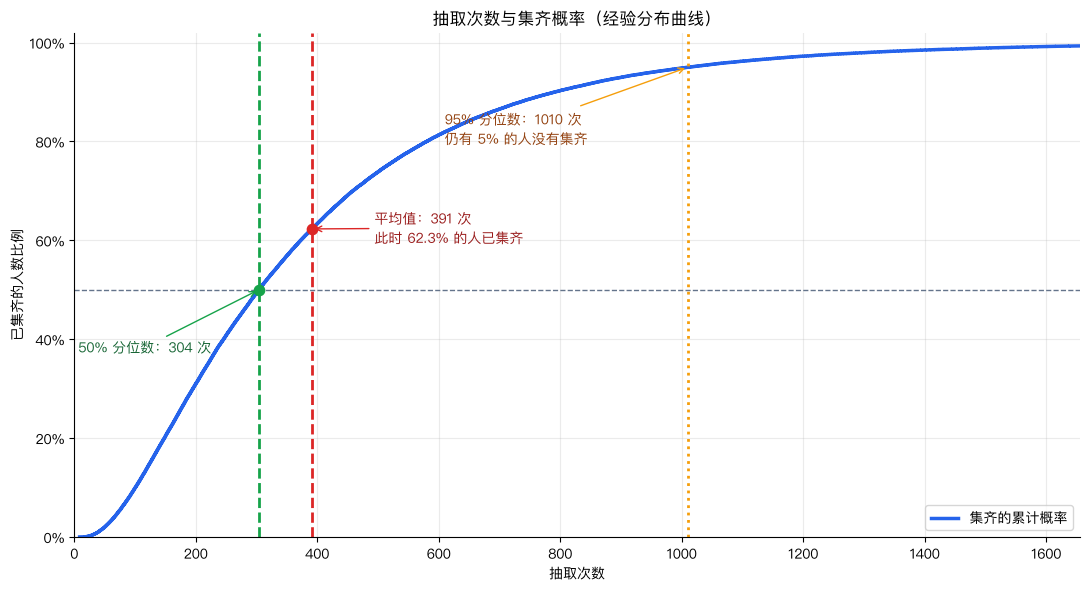

In [27]:
from bisect import bisect_right

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 尽量选择系统中已安装的中文字体
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["PingFang SC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Arial Unicode MS"]:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

sample_count = len(results)
ecdf = [(index + 1) / sample_count for index in range(sample_count)]

average_draws = mean(results)
median_draws = results[int(sample_count * 0.50)]
q95_draws = results[int(sample_count * 0.95)]
q99_draws = results[int(sample_count * 0.99)]
completed_at_average = bisect_right(results, average_draws) / sample_count

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(results, ecdf, color="#2563eb", linewidth=2.5, label="集齐的累计概率")

# 中位数：曲线达到 50% 的位置
ax.axhline(0.50, color="#64748b", linestyle="--", linewidth=1)
ax.axvline(median_draws, color="#16a34a", linestyle="--", linewidth=2)
ax.scatter([median_draws], [0.50], color="#16a34a", s=55, zorder=3)
ax.annotate(
    f"50% 分位数：{median_draws} 次",
    xy=(median_draws, 0.50),
    xytext=(-130, -45),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#16a34a"},
    color="#166534",
)

# 平均数不是 50% 位置：在平均值处，已有约 63% 的人集齐
ax.axvline(average_draws, color="#dc2626", linestyle="--", linewidth=2)
ax.scatter([average_draws], [completed_at_average], color="#dc2626", s=55, zorder=3)
ax.annotate(
    f"平均值：{average_draws:.0f} 次\n此时 {completed_at_average:.1%} 的人已集齐",
    xy=(average_draws, completed_at_average),
    xytext=(45, -10),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#dc2626"},
    color="#991b1b",
)

ax.axvline(q95_draws, color="#f59e0b", linestyle=":", linewidth=2)
ax.annotate(
    f"95% 分位数：{q95_draws} 次\n仍有 5% 的人没有集齐",
    xy=(q95_draws, 0.95),
    xytext=(-175, -55),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#f59e0b"},
    color="#92400e",
)

ax.set_xlim(0, q99_draws * 1.08)
ax.set_ylim(0, 1.02)
ax.set_xlabel("抽取次数")
ax.set_ylabel("已集齐的人数比例")
ax.set_title("抽取次数与集齐概率（经验分布曲线）")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()